In [1]:
import os
ROOT = os.path.dirname(os.path.dirname(os.getcwd()))
print(ROOT)

/home/saisampathkedari/MonteCarlo-Statistical-Methods


In [2]:
import numpy as np
import matplotlib.pyplot as plt
from functools import partial

In [3]:
from utils.montecarlo import *
from mcmc.algorithms.metropolis_hastings import *
from mcmc.utils.mcmc_utils import *
from mcmc.diagnostics.autocorrelation import *

In [4]:
def proposal_rw_sampler(x: np.ndarray, std: float = 1.0) ->np.ndarray:
    """Sample from a random walk proposal with identity covariance."""
    return x + std* np.random.randn(x.shape[0])

def proposal_rw_logpdf(x: np.ndarray, y: np.ndarray, std: float = 1.0) -> float:
    """
    Log-density of the Gaussian random-walk proposal:
        y | x ~ N(x, std^2 * I)
    Probability of moving from x to y (in this case it is symmetric).
    """
    d = x.shape[0]
    delta = y - x
    constant = -0.5*d*np.log(2*np.pi)
    
    logpdf = constant - d*np.log(std) - 0.5*np.dot(delta, delta)/(std * std)
    return logpdf

# Gaussian Distribution 

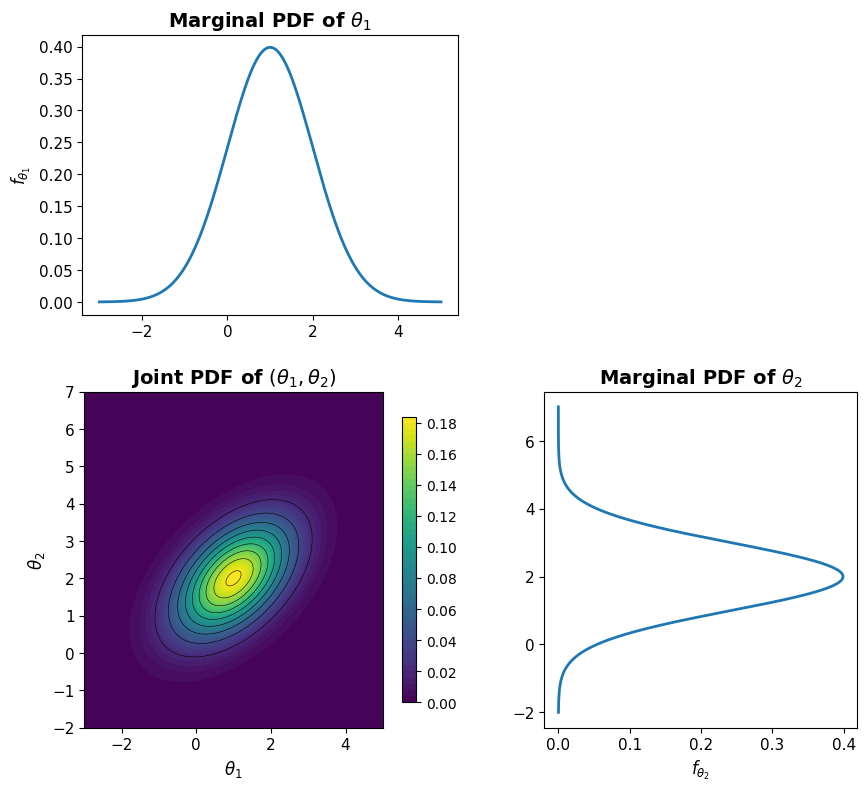

In [5]:
gauss_mean = np.array([1, 2])
gauss_cov = build_2D_covariance_matrix(1.0, 1.0, 0.5) # std, std, correlation

x = np.linspace(-3, 5, 300)
y = np.linspace(-2, 7, 300)

fig, ax = plot_bivariate_gauss(x, y, gauss_mean, gauss_cov)
plt.show()

In [7]:
initial_sample = np.array([10,10])
num_samples = 10000
target_logpdf = lambda x: multivariate_normal_logpdf_eval(x.reshape(1,-1), mean=gauss_mean, cov=gauss_cov)
proposal_logpdf = lambda x, y: proposal_rw_logpdf(x,y, std=2)
proposal_sampler = lambda x: proposal_rw_sampler(x, std=2)

mh_samples = mh_mcmc(initial_sample, num_samples, target_logpdf, proposal_logpdf, proposal_sampler)

samples = mh_samples.samples
print("Accepted Samples Ratio:", mh_samples.accept_rate)

Accepted Samples Ratio: 0.2597259725972597


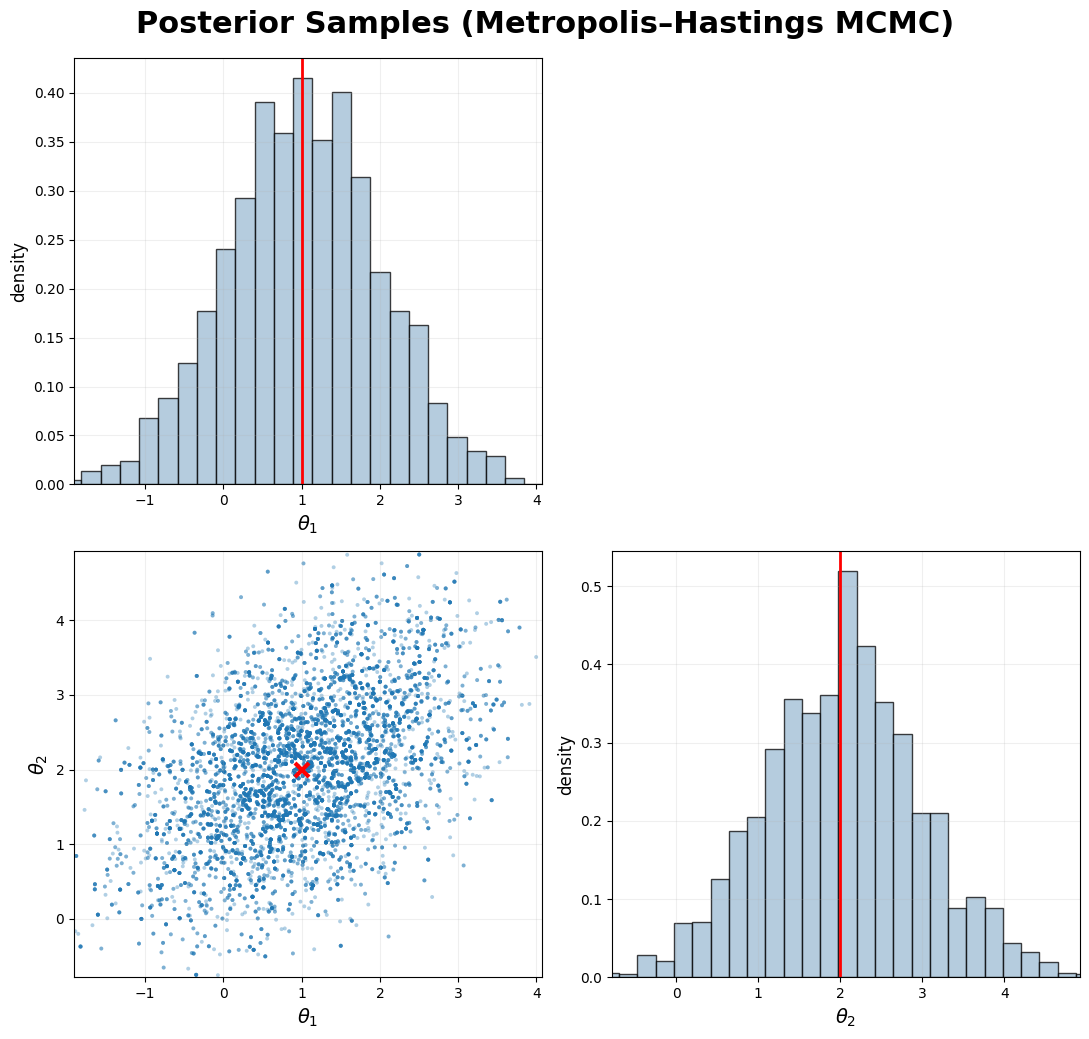

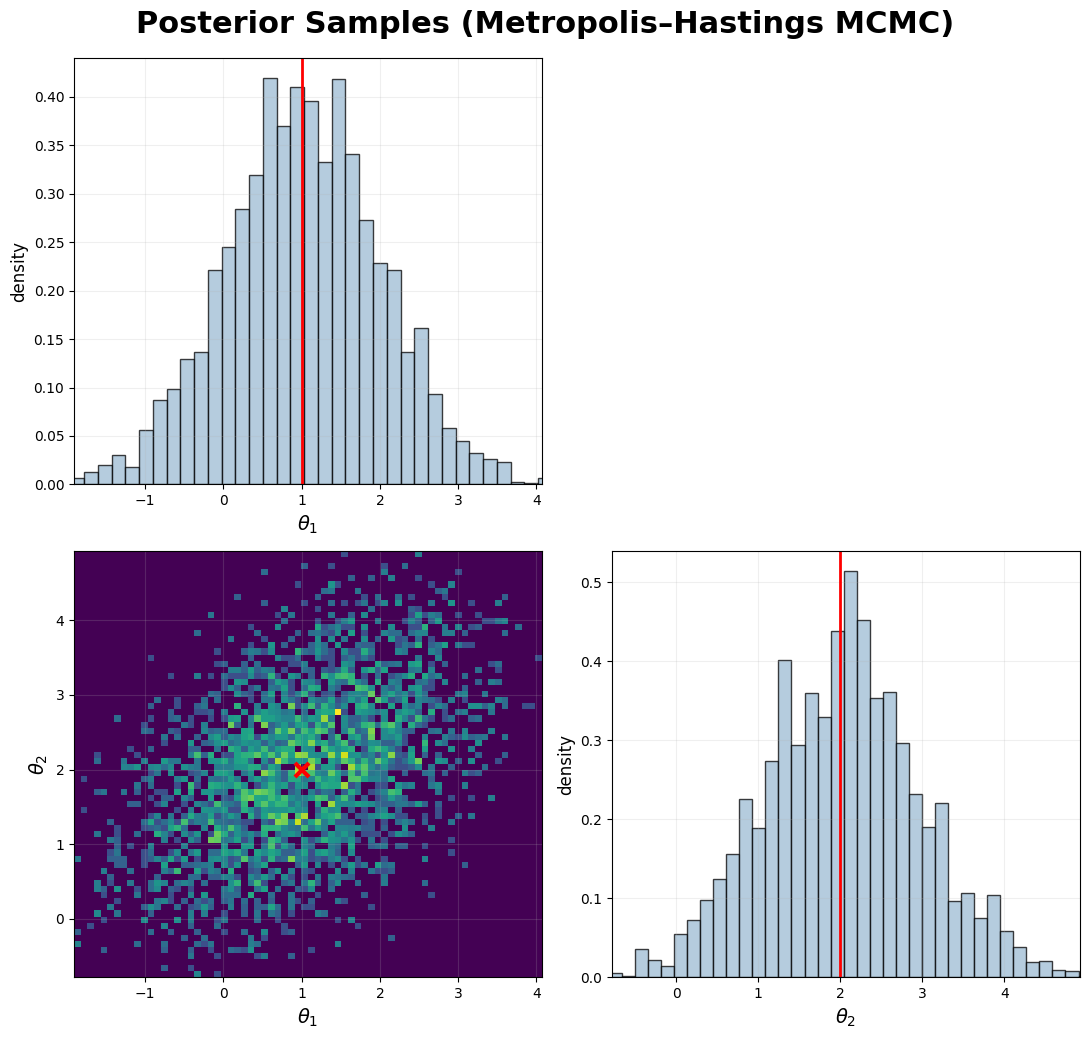

In [8]:
plt.close()
fig, axs, gs = scatter_matrix_clean(
    11,
    [samples],
    truths=gauss_mean,          # or None
    labels=[r"$\theta_1$", r"$\theta_2$"],
    hist_plot=False,
)
plt.show()

plt.close(12)
fig, axs, gs = scatter_matrix_clean(
    12,
    [samples],
    truths=gauss_mean,
    labels=[r"$\theta_1$", r"$\theta_2$"],
    hist_plot=True,
    nbins=70
)
plt.show()

## Mixing

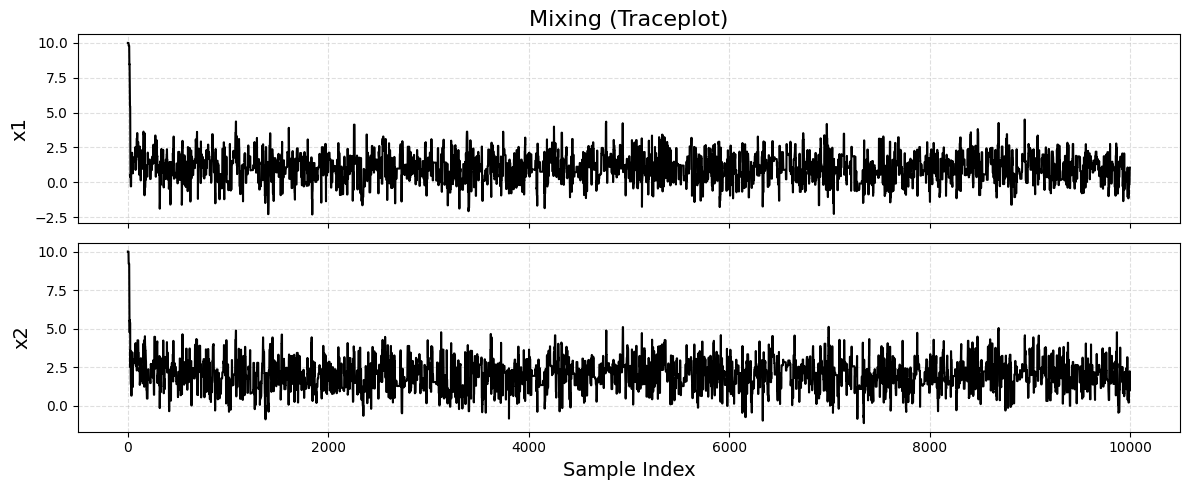

In [9]:
plot_mixing_2d(samples, dim_names=("x1", "x2"))

## Autocorrelation

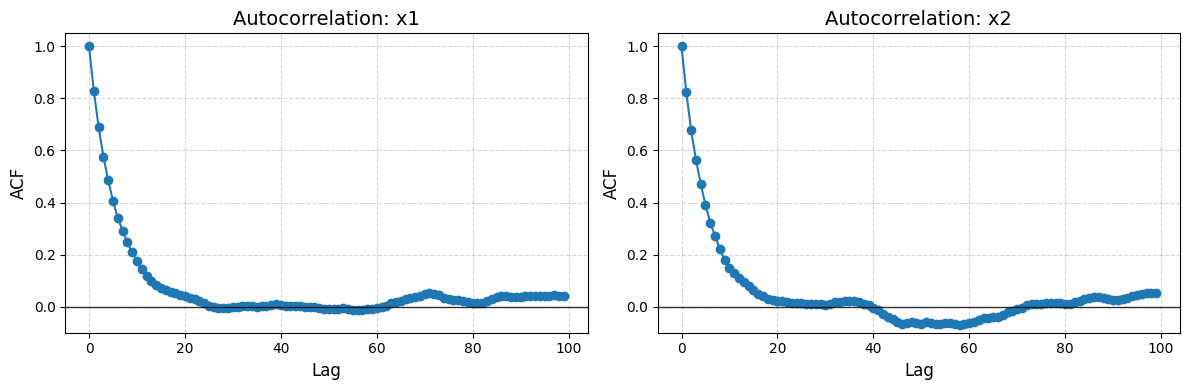

In [ ]:
lags, acf = autocorrelation_vectorized(samples, max_lag=100)
plot_autocorrelation_2d(lags, acf, dim_names=("x1", "x2"))